# Title: Predicting Bank Customer Churn Using Machine Learning

## Problem Statement

Customer churn is a major problem for banks and financial institutions. Losing customers directly affects revenue and business growth. Therefore, companies want to identify customers who are likely to leave their services.

The goal of this project is to build a predictive analytics workflow that analyzes customer data and predicts whether a customer will churn or stay with the bank.

This project uses a customer churn dataset containing demographic information, account details, and transaction behavior.

The target variable is **Attrition_Flag**, which indicates whether a customer has left the bank.

---

# Dataset Description

The dataset contains information about bank customers and their credit card usage.

It includes customer demographics, financial attributes, and transaction behavior.

The dataset contains the following types of features:

- **Demographic features** (Age, Gender, Education, Marital Status)
- **Financial features** (Income Category, Credit Limit)
- **Behavioral features** (Transaction Amount, Transaction Count, Months Inactive)

The dataset contains **10127 rows and 23 columns**.

The main variable we want to predict is **Attrition_Flag**, which indicates whether a customer has churned or remained with the bank.

In [2]:
import pandas as pd

df = pd.read_excel(r"C:\Users\LENOVO\OneDrive\Desktop\Machine learning project\Data\BankChurners.xlsx")

df.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


In [3]:
df.tail()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
10122,772366833,Existing Customer,50,M,2,Graduate,Single,$40K - $60K,Blue,40,...,2,3,4003.0,1851,2152.0,0.703,15476,117,0.857,0.462
10123,710638233,Attrited Customer,41,M,2,Unknown,Divorced,$40K - $60K,Blue,25,...,2,3,4277.0,2186,2091.0,0.804,8764,69,0.683,0.511
10124,716506083,Attrited Customer,44,F,1,High School,Married,Less than $40K,Blue,36,...,3,4,5409.0,0,5409.0,0.819,10291,60,0.818,0.000
10125,717406983,Attrited Customer,30,M,2,Graduate,Unknown,$40K - $60K,Blue,36,...,3,3,5281.0,0,5281.0,0.535,8395,62,0.722,0.000
10126,714337233,Attrited Customer,43,F,2,Graduate,Married,Less than $40K,Silver,25,...,2,4,10388.0,1961,8427.0,0.703,10294,61,0.649,0.189


In [4]:
df.shape

(10127, 21)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CLIENTNUM                 10127 non-null  int64  
 1   Attrition_Flag            10127 non-null  str    
 2   Customer_Age              10127 non-null  int64  
 3   Gender                    10127 non-null  str    
 4   Dependent_count           10127 non-null  int64  
 5   Education_Level           10127 non-null  str    
 6   Marital_Status            10127 non-null  str    
 7   Income_Category           10127 non-null  str    
 8   Card_Category             10127 non-null  str    
 9   Months_on_book            10127 non-null  int64  
 10  Total_Relationship_Count  10127 non-null  int64  
 11  Months_Inactive_12_mon    10127 non-null  int64  
 12  Contacts_Count_12_mon     10127 non-null  int64  
 13  Credit_Limit              10127 non-null  float64
 14  Total_Revolving_B

In [6]:
target = "Attrition_Flag"
print("Target Variable:", target)

Target Variable: Attrition_Flag


In [8]:
numerical_features = df.select_dtypes(include=['int64','float64']).columns
categorical_features = df.select_dtypes(include=['str']).columns

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
Index(['CLIENTNUM', 'Customer_Age', 'Dependent_count', 'Months_on_book',
       'Total_Relationship_Count', 'Months_Inactive_12_mon',
       'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal',
       'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt',
       'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio'],
      dtype='str')

Categorical Features:
Index(['Attrition_Flag', 'Gender', 'Education_Level', 'Marital_Status',
       'Income_Category', 'Card_Category'],
      dtype='str')


In [9]:
df.isnull().sum()

CLIENTNUM                   0
Attrition_Flag              0
Customer_Age                0
Gender                      0
Dependent_count             0
Education_Level             0
Marital_Status              0
Income_Category             0
Card_Category               0
Months_on_book              0
Total_Relationship_Count    0
Months_Inactive_12_mon      0
Contacts_Count_12_mon       0
Credit_Limit                0
Total_Revolving_Bal         0
Avg_Open_To_Buy             0
Total_Amt_Chng_Q4_Q1        0
Total_Trans_Amt             0
Total_Trans_Ct              0
Total_Ct_Chng_Q4_Q1         0
Avg_Utilization_Ratio       0
dtype: int64

In [10]:
df.describe()

,CLIENTNUM,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
count,1.012700e+04,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000
mean,7.391776e+08,46.325960,2.346203,35.928409,3.812580,2.341167,2.455317,8631.953698,1162.814061,7469.139637,0.759941,4404.086304,64.858695,0.712222,0.274894
std,3.690378e+07,8.016814,1.298908,7.986416,1.554408,1.010622,1.106225,9088.776650,814.987335,9090.685324,0.219207,3397.129254,23.472570,0.238086,0.275691
min,7.080821e+08,26.000000,0.000000,13.000000,1.000000,0.000000,0.000000,1438.300000,0.000000,3.000000,0.000000,510.000000,10.000000,0.000000,0.000000
25%,7.130368e+08,41.000000,1.000000,31.000000,3.000000,2.000000,2.000000,2555.000000,359.000000,1324.500000,0.631000,2155.500000,45.000000,0.582000,0.023000
50%,7.179264e+08,46.000000,2.000000,36.000000,4.000000,2.000000,2.000000,4549.000000,1276.000000,3474.000000,0.736000,3899.000000,67.000000,0.702000,0.176000
75%,7.731435e+08,52.000000,3.000000,40.000000,5.000000,3.000000,3.000000,11067.500000,1784.000000,9859.000000,0.859000,4741.000000,81.000000,0.818000,0.503000
max,8.283431e+08,73.000000,5.000000,56.000000,6.000000,6.000000,6.000000,34516.000000,2517.000000,34516.000000,3.397000,18484.000000,139.000000,3.714000,0.999000


In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

# Histogram

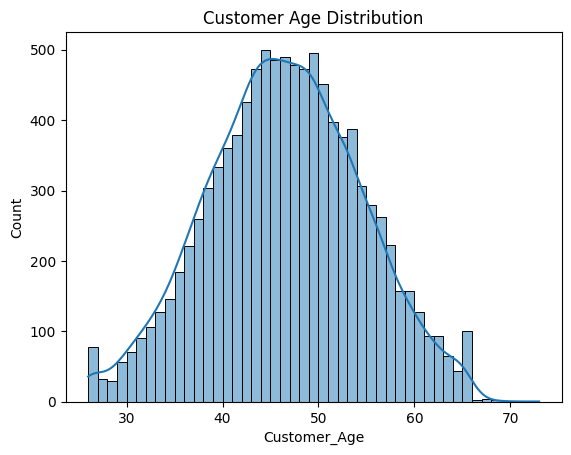

In [12]:
sns.histplot(df['Customer_Age'], kde=True)
plt.title("Customer Age Distribution")
plt.show()

### Interpretation
The histogram shows the distribution of customer ages. It helps understand the age group distribution in the dataset.

# Boxplot

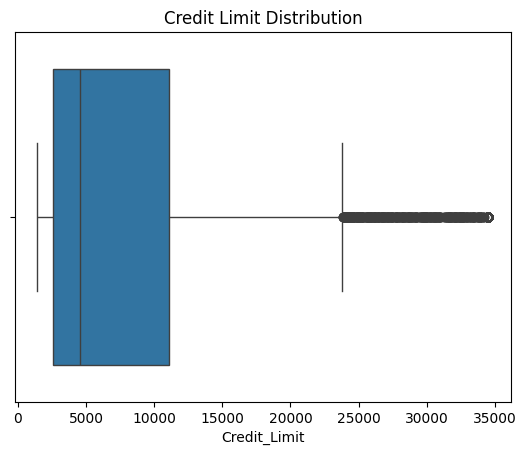

In [15]:
sns.boxplot(x=df['Credit_Limit'])
plt.title("Credit Limit Distribution")
plt.show()

## Interpretation

The boxplot shows the distribution of customer credit limits.

Most customers have credit limits between approximately 2,000 and 12,000. However, several outliers exist with credit limits above 25,000.

This indicates that while most customers have moderate credit limits, a small number of customers have significantly higher credit limits, likely representing premium or high-value clients.

# Scatter Plot

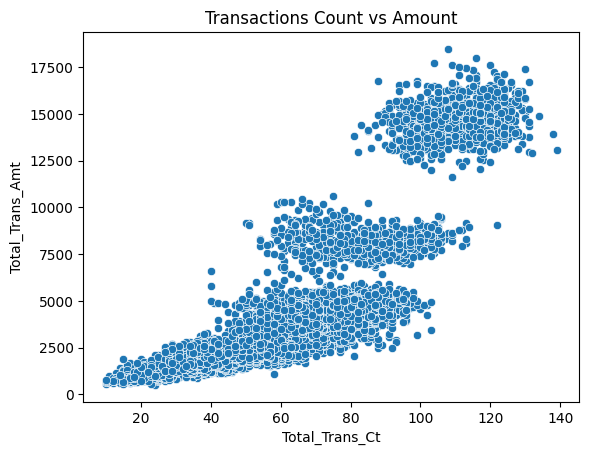

In [16]:
sns.scatterplot(x='Total_Trans_Ct', y='Total_Trans_Amt', data=df)
plt.title("Transactions Count vs Amount")
plt.show()

## Interpretation

The scatter plot shows the relationship between transaction count and transaction amount.

# Correlation Heatmap

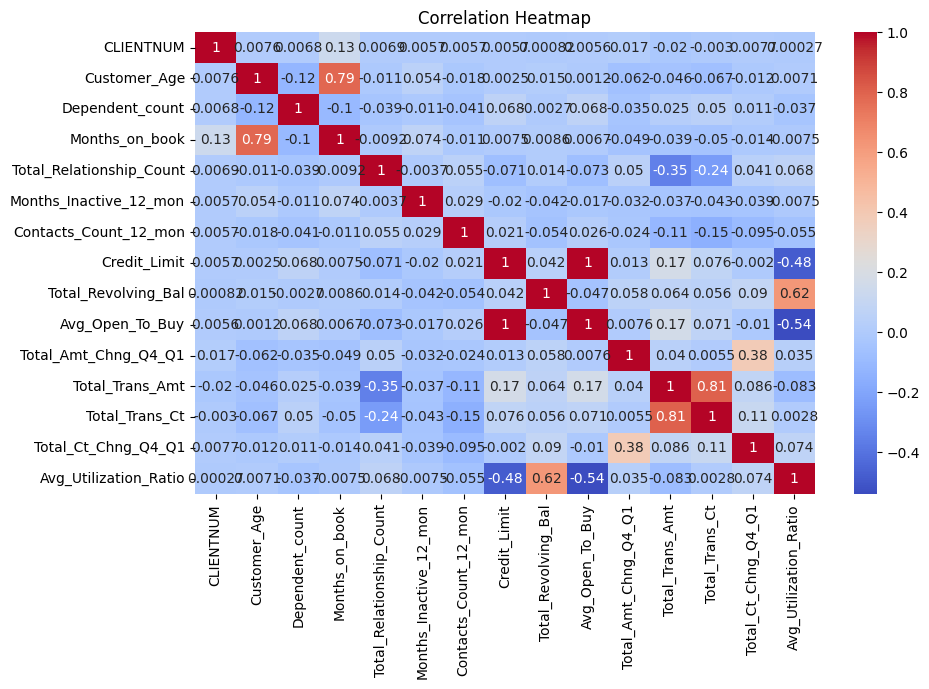

In [17]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

## Interpretation

The heatmap shows correlations between numerical variables in the dataset. This helps identify relationships between features.

- **+1** → Strong positive relationship
- **0** → No relationship
- **-1** → Strong negative relationship

- 🔴 **Red** → Strong positive correlation
- 🔵 **Blue** → Negative correlation
- ⚪ **Light color** → Weak correlation

# Category Comparison

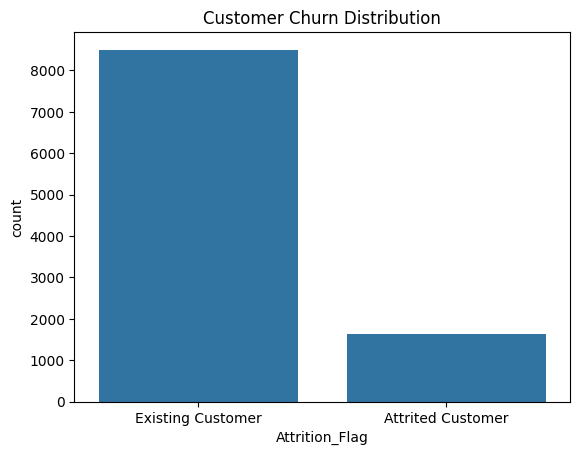

In [18]:
sns.countplot(x='Attrition_Flag', data=df)
plt.title("Customer Churn Distribution")
plt.show()

## Interpretation

This chart shows how many customers have churned and how many remain with the bank.

## Key Observations

- Most customers are in the age range of 40–50 years.
- Customers with higher transaction counts tend to have higher transaction amounts.
- The dataset shows a class imbalance, with more existing customers than churned customers.
- Credit limit values vary widely among customers.

In [20]:
df.to_csv("day1_ml_output.csv", index=False)